# Indiana Pines

1. Import dependencies

In [ ]:
import random
import torch
import numpy as np

import torch.utils.data as data

from torch import nn

from torch.optim.lr_scheduler import StepLR

from src.util.hsi import (
    extract_patches,
    DimReductionType,
    PreProcessType,
    preprocess_hsi,
    extract_band_patches,
    train_test_band_patch_split,
    reduce_hsi_dim,
)
from src.model.spectral_former import SpectralFormer
from src.util.torch import resolve_torch_device
from src.data.indian_pines import load_indian_pines
from src.visualization.plot import plot_segmentation_comparison, plot_epoch_generic
from src.data.dataset_decorator import UnlabeledDatasetDecorator
from src.trainer.co_trainer import BiCoTrainer
from src.model.ensemble import Ensemble
from src.trainer.base_trainer import AdamOptimizedModule
from src.trainer.classification_trainer import ClassificationTrainer
from src.util.reporting import (
    classification_trainer,
    create_model_name,
    report_run,
    read_report_to_show,
)
from src.util.dict_ext import list_to_dict

2. Prepare env

In [2]:
dim = 32
depth = 5
heads = 4
mlp_dim = 8
dropout = 0.3
emb_dropout = 0.1
learning_rate = 5e-4
weight_decay = 5e-3
num_epochs = 300
scheduler_step_size = num_epochs // 10
scheduler_gamma = 0.9

In [3]:
batch_size = 64
patch_size = 7
band_patch = 3

target_dim = 75

pre_process_type = PreProcessType.STANDARTIZATION
dim_reduction_type = DimReductionType.PCA

In [4]:
random_seed = 42

random.seed(random_seed)
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = resolve_torch_device()

generator = torch.Generator()
generator.manual_seed(random_seed)

In [5]:
f"Device is {device}"

'Device is cuda'

3. Load dataset

In [6]:
image, labels = load_indian_pines()

image_h, image_w, image_c = image.shape

In [7]:
_, image = preprocess_hsi(image, pre_process_type)

In [8]:
num_classes = len(np.unique(labels))

f"Number of classes {num_classes}"

'Number of classes 17'

In [39]:
examples_per_class = [20] * num_classes

4. Reduce dimensions

In [ ]:
_, target_dim, image = reduce_hsi_dim(
    image, target_dim, dim_reduction_type, random_seed
)

5. Prepare dataset

In [11]:
print(f"Image shape: {image.shape}")

x, y = extract_patches(image, labels, patch_size)

print(f"Patched image shape: {x.shape}")
print(f"Patched labels shape: {y.shape}")

x = extract_band_patches(x, band_patch)

print(f"Bandwise patched image shape: {x.shape}")

Image shape: (145, 145, 75)
Patched image shape: (21025, 7, 7, 75)
Patched labels shape: (21025,)
Bandwise patched image shape: (21025, 147, 75)


In [48]:
x_train, y_train, x_test, y_test, y_masked = train_test_band_patch_split(
    x, y, examples_per_class, "indian_pines"
)

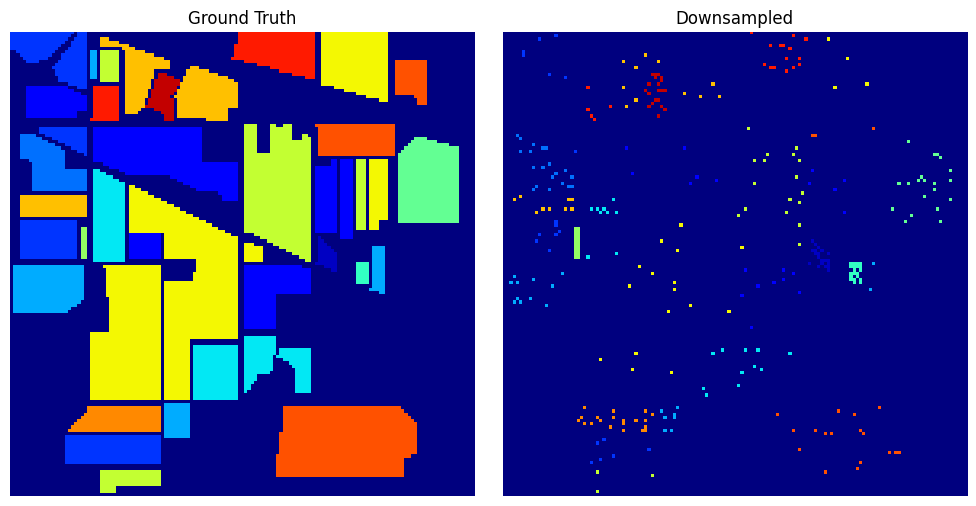

In [13]:
plot_segmentation_comparison(labels, y_masked.reshape(labels.shape), title2="Downsampled")

In [14]:
x_train.shape

(340, 147, 75)

In [15]:
x_all = torch.tensor(x, dtype=torch.float32, device=device).permute(0, 2, 1)
y_all = torch.tensor(y, dtype=torch.long, device=device)
x_train = torch.tensor(x_train, dtype=torch.float32, device=device).permute(0, 2, 1)
y_train = torch.tensor(y_train, dtype=torch.long, device=device)
x_test = torch.tensor(x_test, dtype=torch.float32, device=device).permute(0, 2, 1)
y_test = torch.tensor(y_test, dtype=torch.long, device=device)

In [16]:
train_dataset = data.TensorDataset(x_train, y_train)
test_dataset = data.TensorDataset(x_test, y_test)
full_dataset = data.TensorDataset(x_all, y_all)

In [17]:
train_loader = data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=generator,
)
test_loader = data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    generator=generator,
)
full_loader = data.DataLoader(
    full_dataset,
    batch_size=batch_size,
    shuffle=False,
    generator=generator,
)
predict_loader = data.DataLoader(
    UnlabeledDatasetDecorator(full_dataset),
    batch_size=batch_size,
    shuffle=False,
    generator=generator,
)

In [18]:
f"Training samples: {len(train_dataset)}, Testing samples: {len(test_dataset)}"

'Training samples: 340, Testing samples: 20685'

6. Train semi-supervised model

In [19]:
model_1 = AdamOptimizedModule(
    SpectralFormer(
        image_size=patch_size,
        near_band=band_patch,
        num_patches=target_dim,
        num_classes=num_classes,
        dim=dim,
        depth=depth,
        heads=heads,
        mlp_dim=mlp_dim,
        dropout=dropout,
        emb_dropout=emb_dropout,
    ),
    lr=learning_rate,
    weight_decay=weight_decay,
    scheduler=lambda opt: StepLR(
        opt, step_size=scheduler_step_size, gamma=scheduler_gamma
    ),
)

model_2 = AdamOptimizedModule(
    SpectralFormer(
        image_size=patch_size,
        near_band=band_patch,
        num_patches=target_dim,
        num_classes=num_classes,
        dim=dim,
        depth=depth,
        heads=heads,
        mlp_dim=mlp_dim,
        dropout=dropout,
        emb_dropout=emb_dropout,
    ),
    lr=learning_rate,
    weight_decay=weight_decay,
    scheduler=lambda opt: StepLR(
        opt, step_size=scheduler_step_size, gamma=scheduler_gamma
    ),
)

loss = nn.CrossEntropyLoss()

trainer = ClassificationTrainer(
    num_epochs=num_epochs,
    num_classes=num_classes,
    criterion=loss,
    device=device,
    record_history=False,
    dl_accumulation_steps=2,
)

co_trainer = BiCoTrainer(
    batch_size=batch_size,
    confidence_threshold=0.9,
    generator=generator,
    trainer=trainer,
)

In [20]:
feedback = co_trainer.fit(
    models=(model_1, model_2),
    labeled=train_dataset,
    unlabeled=test_dataset,
    eval_dl=test_loader,
)

0it [00:00, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

In [21]:
feedback.history[-1].eval

{'eval_f1': 0.26959019899368286,
 'eval_accuracy_overall': 0.6728171110153198,
 'eval_accuracy_avg': 0.3397631049156189,
 'eval_kappa': 0.29724037647247314,
 'eval_loss': 4.271469592128271}

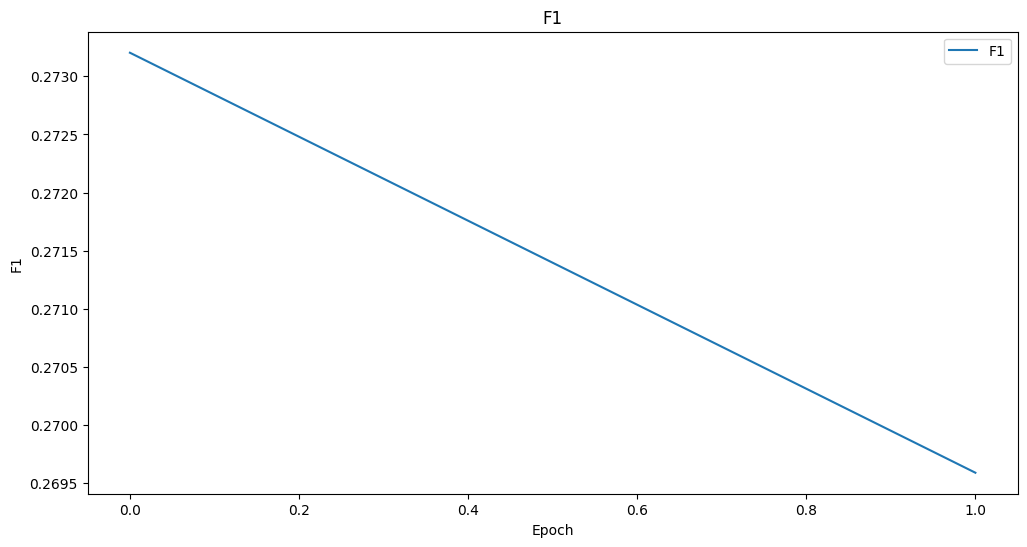

In [22]:
plot_epoch_generic(
    [it.eval["eval_f1"] for it in feedback.history], desc="F1"
)

In [23]:
co_trained = Ensemble([model_1, model_2])

In [24]:
validation_result = trainer.validate(co_trained, full_loader)

validation_result

{'eval_f1': 0.2770960032939911,
 'eval_accuracy_overall': 0.7399674654006958,
 'eval_accuracy_avg': 0.3503924012184143,
 'eval_kappa': 0.3086095452308655,
 'eval_loss': 4.198041504277285}

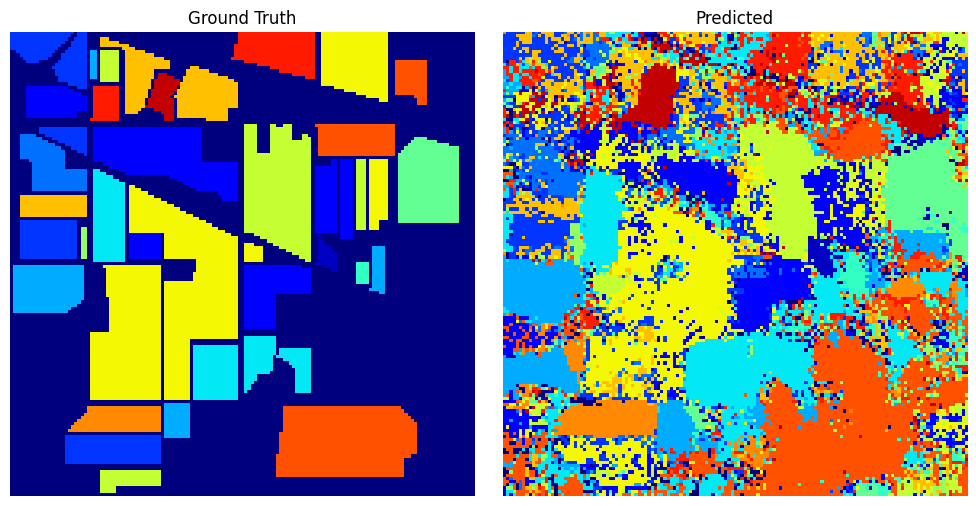

In [25]:
_, y_pred = trainer.predict(co_trained, predict_loader)
y_pred = torch.cat(y_pred, dim=0)
y_pred = torch.argmax(y_pred, dim=1)
y_pred = y_pred.reshape(image_h, image_w)

plot_segmentation_comparison(labels, y_pred.cpu().numpy())

6. Write report

In [ ]:

model_name = create_model_name("indian_pines_", list_to_dict(examples_per_class))
model_category = "specteal_former_co_training"

report_run(
    model_name=model_name,
    model_category=model_category,
    run_desc="Default run",
    run_params={
        "hidden_dim": dim,
        "num_layers": depth,
        "num_heads": heads,
        "mlp_dim": mlp_dim,
        "dropout": dropout,
        "emb_dropout": emb_dropout,
        "scheduler_step_size": scheduler_step_size,
        "scheduler_gamma": scheduler_gamma,
        "weight_decay": weight_decay,
        "learning_rate": learning_rate,
        "num_epochs": num_epochs,
        "batch_size": batch_size,
        "patch_size": patch_size,
        "target_dim": target_dim,
        "pre_process_type": str(pre_process_type),
        "dim_reduction_type": str(dim_reduction_type),
    },
    run_metrics=classification_trainer(validation_result),
)

PosixPath('/home/melal/Workspace/hsi-classification-playground/reports/runs/indian_pines__0-20_1-20_2-20_3-20_4-20_5-20_6-20_7-20_8-20_9-20_10-20_11-20_12-20_13-20_14-20_15-20_16-20.csv')

In [44]:
read_report_to_show(model_name, sort_by_metric="f1")

,timestamp,model_category,run_desc,params,loss,f1,OA,AA,kappa
64,2025-05-31T12:52:12.314211+00:00,lenet_multiview,"New fixed mask, 2 epochs, new unlabled shrinking","{""num_epochs"": 15, ""batch_size"": 32, ""patch_si...",NaN,0.790402,0.878032,0.787206,0.703928
67,2025-05-31T18:17:32.920559+00:00,lenet_multiview,"New fixed mask, 2 epoch, new unlabled shrinking","{""num_epochs"": 15, ""batch_size"": 32, ""patch_si...",NaN,0.790402,0.878032,0.787206,0.703928
81,2025-06-03T12:14:50.003049+00:00,lenet_multiview,"DBDA_v2, 3 epochs, new unlabled shrinking, mor...","{""num_epochs"": 30, ""batch_size"": 32, ""patch_si...",NaN,0.770723,0.860694,0.773365,0.676614
62,2025-05-30T20:38:12.198151+00:00,lenet_multiview,"New fixed mask, less epochs","{""num_epochs"": 15, ""batch_size"": 32, ""patch_si...",NaN,0.761022,0.824273,0.768847,0.657544
72,2025-06-01T11:04:28.706267+00:00,lenet_multiview,"Self learning, 8 epochs, new unlabled shrinkin...","{""num_epochs"": 30, ""batch_size"": 32, ""patch_si...",NaN,0.760632,0.838244,0.765612,0.657339
...,...,...,...,...,...,...,...,...,...
22,2025-05-25T14:39:13.847478+00:00,specteal_former_co_training,Default run,"{""hidden_dim"": 32, ""num_layers"": 5, ""num_heads...",2.814270,0.179225,0.430531,0.176266,0.130307
10,2025-05-25T09:30:05.188620+00:00,vit,Add weight decay,"{""hidden_dim"": 64, ""num_layers"": 5, ""num_heads...",5.515652,0.177391,0.052552,0.143306,0.060421
73,2025-06-01T20:02:30.458685+00:00,vit,"Fixed mask, add weight decay, increase dropout...","{""num_epochs"": 300, ""batch_size"": 64, ""patch_s...",2.716200,0.168771,0.048153,0.131034,0.049644
24,2025-05-25T16:13:53.131416+00:00,lenet_co_training,"Less epochs, no scheduling","{""learning_rate"": 0.001, ""num_epochs"": 30, ""ba...",2.827521,0.147750,0.677064,0.252176,0.225479


In [45]:
read_report_to_show(model_name, sort_by_metric="f1", model_category=model_category)

,timestamp,run_desc,params,loss,f1,OA,AA,kappa
82,2025-08-04T12:15:45.838985+00:00,Default run,"{""hidden_dim"": 32, ""num_layers"": 5, ""num_heads...",4.198042,0.277096,0.739967,0.350392,0.308610
22,2025-05-25T14:39:13.847478+00:00,Default run,"{""hidden_dim"": 32, ""num_layers"": 5, ""num_heads...",2.814270,0.179225,0.430531,0.176266,0.130307
